# Ex. Regressão Linear Múltipla - Raphael Fleury

## Análise Exploratória

### Importando o dataset

In [4]:
import pandas as pd

df = pd.read_csv("Exercicio_Producao.csv")
df.head()

,Data,Quantidade Produzida,Quantidade de Maquinas,Quantidade de Trabalhadores,Horas Trabalhadas,Feriado
0,01/01/2023,6285,11,12,6,1
1,02/01/2023,9482,8,23,11,0
2,03/01/2023,10548,15,22,10,0
3,04/01/2023,10990,12,27,11,0
4,05/01/2023,8763,9,26,7,0


### Verificando o tipo de dados e a presença de valores nulos

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Data                         365 non-null    object
 1   Quantidade Produzida         365 non-null    int64 
 2   Quantidade de Maquinas       365 non-null    int64 
 3   Quantidade de Trabalhadores  365 non-null    int64 
 4   Horas Trabalhadas            365 non-null    int64 
 5   Feriado                      365 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 17.2+ KB


Necessário apenas converter o campo "Data" para o tipo datetime

In [6]:
df["Data"] = pd.to_datetime(df["Data"], format="%d/%m/%Y")

### Buscando outliers

In [7]:
df.describe()

,Data,Quantidade Produzida,Quantidade de Maquinas,Quantidade de Trabalhadores,Horas Trabalhadas,Feriado
count,365,365.000000,365.000000,365.000000,365.000000,365.000000
mean,2023-07-02 00:00:00,8848.852055,9.764384,21.830137,8.950685,0.027397
min,2023-01-01 00:00:00,5300.000000,5.000000,11.000000,6.000000,0.000000
25%,2023-04-02 00:00:00,7794.000000,7.000000,18.000000,7.000000,0.000000
50%,2023-07-02 00:00:00,8928.000000,10.000000,22.000000,9.000000,0.000000
75%,2023-10-01 00:00:00,9907.000000,12.000000,26.000000,11.000000,0.000000
max,2023-12-31 00:00:00,12141.000000,15.000000,29.000000,12.000000,1.000000
std,NaN,1378.208167,3.141243,4.412603,2.022614,0.163462


Nada fora do esperado.

### Analisando correlação entre as variáveis

In [8]:
df.corr()

,Data,Quantidade Produzida,Quantidade de Maquinas,Quantidade de Trabalhadores,Horas Trabalhadas,Feriado
Data,1.000000,-0.080412,-0.119419,-0.023562,0.003656,0.011310
Quantidade Produzida,-0.080412,1.000000,0.650871,0.538633,0.626836,-0.210277
Quantidade de Maquinas,-0.119419,0.650871,1.000000,0.037141,0.142587,-0.035547
Quantidade de Trabalhadores,-0.023562,0.538633,0.037141,1.000000,0.049848,-0.260145
Horas Trabalhadas,0.003656,0.626836,0.142587,0.049848,1.000000,0.020717
Feriado,0.011310,-0.210277,-0.035547,-0.260145,0.020717,1.000000


## Regressão Linear

### Criação de dataset de treino

In [9]:
from sklearn.model_selection import train_test_split

# Remove coluna de data, pois não gera informação útil para o modelo
# Separa a variável alvo em y e as variáveis de entrada em X
target = "Quantidade Produzida"
X = df.drop(columns=["Data", target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)

### Escolha de modelo

#### LinearRegression (Baseline)
- Simples, sem parâmetros críticos
- **Caso de uso:** dados bem-preparados, sem multicolinearidade severa

#### Ridge
- **alpha** = força da regularização (padrão: 1.0)
- **Caso de uso:** features correlacionadas, evitar overfitting

#### Lasso
- **alpha** = força da regularização
- **Caso de uso:** eliminar features irrelevantes

#### ElasticNet
- Combina Ridge + Lasso
- **alpha**: força geral (0.1-1.0)
- **l1_ratio**: 0=Ridge, 1=Lasso, 0.5=balanço

#### Características do dataset

Variáveis lógicas e bem-correlacionadas com a produção:

In [10]:
df.corr()[target].drop([target, "Data"]).sort_values(ascending=False)

,Quantidade Produzida
Quantidade de Maquinas,0.650871
Horas Trabalhadas,0.626836
Quantidade de Trabalhadores,0.538633
Feriado,-0.210277


Baixo risco de multicolinearidade entre as features:

In [11]:
# Obter correlações entre features (sem target)
corr_matrix = df.drop(columns=["Data", target]).corr()

# Extrair pares únicos de correlações
correlacoes = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        valor = corr_matrix.iloc[i, j]
        correlacoes.append((col1, col2, valor))

# Ordenar por correlação (maior primeiro)
correlacoes.sort(key=lambda x: abs(x[2]), reverse=True)

# Exibir
print("Maiores correlações entre features:\n")
for i, (col1, col2, valor) in enumerate(correlacoes, 1):
    print(f"{i}. {col1} x {col2}: {valor:.4f}")

Maiores correlações entre features:

1. Quantidade de Trabalhadores x Feriado: -0.2601
2. Quantidade de Maquinas x Horas Trabalhadas: 0.1426
3. Quantidade de Trabalhadores x Horas Trabalhadas: 0.0498
4. Quantidade de Maquinas x Quantidade de Trabalhadores: 0.0371
5. Quantidade de Maquinas x Feriado: -0.0355
6. Horas Trabalhadas x Feriado: 0.0207


In [12]:
df.corr().drop([target, "Data"]).sort_values(by=target, ascending=False)

,Data,Quantidade Produzida,Quantidade de Maquinas,Quantidade de Trabalhadores,Horas Trabalhadas,Feriado
Quantidade de Maquinas,-0.119419,0.650871,1.000000,0.037141,0.142587,-0.035547
Horas Trabalhadas,0.003656,0.626836,0.142587,0.049848,1.000000,0.020717
Quantidade de Trabalhadores,-0.023562,0.538633,0.037141,1.000000,0.049848,-0.260145
Feriado,0.011310,-0.210277,-0.035547,-0.260145,0.020717,1.000000


#### Modelo escolhido: LinearRegression
O modelo mais básico já é suficiente neste caso.

### Utilização do modelo escolhido

Treino do modelo:

In [13]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

Predições:

In [14]:
y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)

#### Avaliação do Modelo

In [15]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Métricas de Treinamento
r2_train = r2_score(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_train = mean_absolute_error(y_train, y_pred_train)

# Métricas de Teste
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)

print("=" * 50)
print("RESULTADOS DO MODELO LINEAR")
print("=" * 50)
print("\n📊 TREINO:")
print(f"  R² Score: {r2_train:.4f}")
print(f"  RMSE: {rmse_train:.2f} unidades")
print(f"  MAE: {mae_train:.2f} unidades")

print("\n📊 TESTE:")
print(f"  R² Score: {r2_test:.4f}")
print(f"  RMSE: {rmse_test:.2f} unidades")
print(f"  MAE: {mae_test:.2f} unidades")

print("\n" + "=" * 50)

RESULTADOS DO MODELO LINEAR

📊 TREINO:
  R² Score: 0.9574
  RMSE: 282.94 unidades
  MAE: 187.95 unidades

📊 TESTE:
  R² Score: 0.9771
  RMSE: 211.17 unidades
  MAE: 172.39 unidades



#### Coeficientes do Modelo

In [16]:
# Exibir coeficientes
print("\n📌 COEFICIENTES:")
print(f"  Intercepto: {modelo.intercept_:.4f}\n")

for feature, coef in zip(X.columns, modelo.coef_):
    print(f"  {feature}: {coef:.4f}")


📌 COEFICIENTES:
  Intercepto: 68.8370

  Quantidade de Maquinas: 242.0373
  Quantidade de Trabalhadores: 149.1740
  Horas Trabalhadas: 356.1545
  Feriado: -693.0910


#### Visualizações

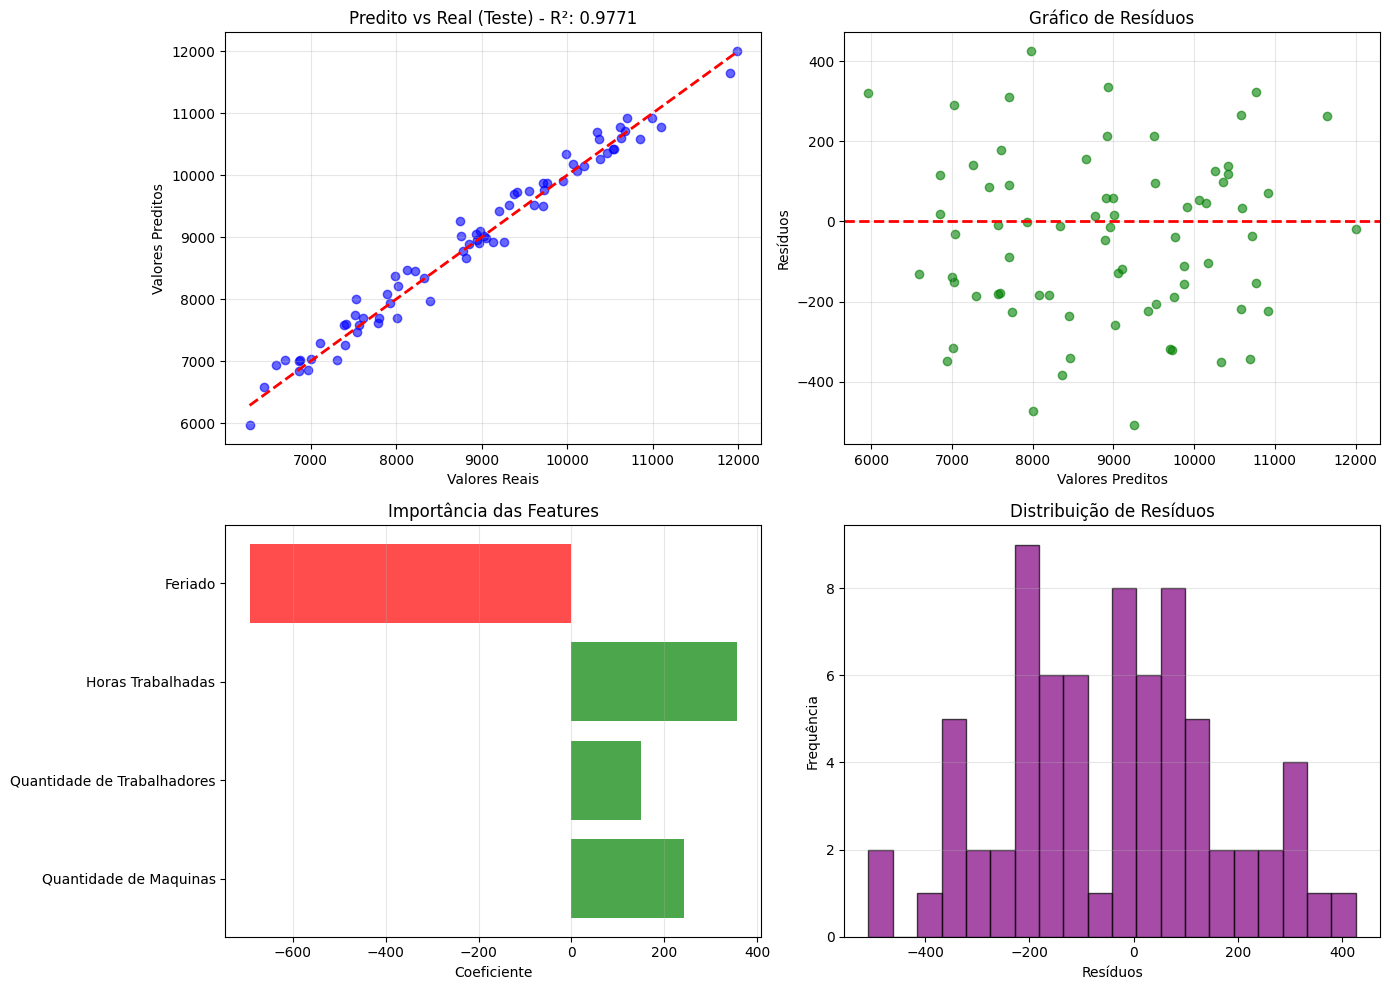

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Predito vs Real (Teste)
axes[0, 0].scatter(y_test, y_pred_test, alpha=0.6, color='blue')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Valores Reais')
axes[0, 0].set_ylabel('Valores Preditos')
axes[0, 0].set_title(f'Predito vs Real (Teste) - R²: {r2_test:.4f}')
axes[0, 0].grid(True, alpha=0.3)

# 2. Resíduos
residuos = y_test - y_pred_test
axes[0, 1].scatter(y_pred_test, residuos, alpha=0.6, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Valores Preditos')
axes[0, 1].set_ylabel('Resíduos')
axes[0, 1].set_title('Gráfico de Resíduos')
axes[0, 1].grid(True, alpha=0.3)

# 3. Coeficientes (Importância)
features = X.columns
coefs = modelo.coef_
colors = ['green' if c > 0 else 'red' for c in coefs]
axes[1, 0].barh(features, coefs, color=colors, alpha=0.7)
axes[1, 0].set_xlabel('Coeficiente')
axes[1, 0].set_title('Importância das Features')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Distribuição de Resíduos
axes[1, 1].hist(residuos, bins=20, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_xlabel('Resíduos')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].set_title('Distribuição de Resíduos')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()